# jnormcorre vs. Suite2P registration — and on to extraction

Compares the two motion-correction backends on a real local 2P recording (the canonical
Suite2P example dataset), then runs ROI detection + fluorescence extraction on each.

1. load a plane of `suite2p_example_data` with `TiffImaging`
2. **register** — both backends; compare mean image + deltas, frame-to-template correlation
   (violin), per-frame shift traces, runtime
3. **sweep jnormcorre params** — is the chosen setting best, and what drives the variability?
4. **extract** — segment each registered movie with **Cellpose-SAM** and pull fluorescence traces
5. **match ROIs by coordinate** and compare matched traces across backends

Environment notes:
- jnormcorre's released build calls `jax.numpy.fix` (removed in JAX 0.10) -> the optional dep
  pins `jax<0.10`. Install: `pip install -e ".[jnormcorre-registration]"`.
- **Segmentation uses Cellpose-SAM (`cpsam`) run directly on the mean image.** Suite2P's own
  detectors are unusable in this stack: `sparsery` crashes on a non-scalar spatial scale,
  `sourcery` over-detects (~1200 ROIs / ~49% FOV at default threshold), and the suite2p cellpose
  wrapper mis-drives the scale-agnostic `cpsam` (3 ROIs). See the segmentation-findings note for
  the full bug list and fixes. Cellpose-SAM run directly gives ~90 sane ROIs.
- Cellpose-SAM on CPU is slow (~4-5 min / image); masks are cached to `~/.cache/pm_jnc_notebook`
  so re-execution is fast.


## 0. Imports

In [1]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

import photon_mosaic as pm
from photon_mosaic.extractors import TiffImaging
from photon_mosaic.preprocessing import (
    Suite2pRegistrationSettings, compute_motion_suite2p, register_suite2p,
    JNormcorreRegistrationSettings, compute_motion_jnormcorre, register_jnormcorre,
)
from photon_mosaic.segmentation.suite2p_segmentation import Suite2pDetectedRois

warnings.filterwarnings("ignore")
%matplotlib inline

/Users/lauraporta/Source/github/photon-mosaic/photon-mosaic-jnormcorre/pm-test-jnormcorre/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load local data

Single-plane 2P recording; one 200-frame acquisition file. Bump `N_FRAMES`/`TIFF` for more.

In [2]:
TIFF = "/Users/lauraporta/local_data/suite2p_example_data/4/file_00002_00001.tif"
FS = 30.0
N_FRAMES = 200

imaging = TiffImaging(file_path=TIFF, sampling_frequency=FS)
N = min(N_FRAMES, imaging.get_num_samples())
H, W = imaging.shape[0], imaging.shape[1]
print(f"shape={imaging.shape}  planes={imaging.num_planes}  frames={imaging.get_num_samples()}  using N={N}")


# (n, H, W) frames for plane 0 from any imaging/registered object
def plane_series(reg, n=N):
    v = reg.epochs[0].get_series(0, n)
    return v[..., 0] if v.ndim == 4 else v


# Mean Pearson r of each frame to a reference template (higher = better aligned)
def frame_to_template_corr(reg, template, n=N):
    ref = np.asarray(template).ravel()
    return np.array([np.corrcoef(f.ravel(), ref)[0, 1] for f in plane_series(reg, n)])


# Boolean union of all ROI footprints (H, W)
def roi_union(rois):
    masks = rois.get_roi_image_masks()
    if masks.ndim == 4:
        masks = masks[..., 0]
    u = masks.any(axis=0)
    del masks
    return u


raw = plane_series(imaging)
raw_template = raw.mean(0)
raw_corr = frame_to_template_corr(imaging, raw_template)
print(f"raw frame->mean correlation: {raw_corr.mean():.4f}")

shape=(662, 788, 1)  planes=1  frames=200  using N=200


raw frame->mean correlation: 0.4956


## 2. Register — Suite2P

In [3]:
t0 = time.time()
motion_s2p = compute_motion_suite2p(
    imaging, settings=Suite2pRegistrationSettings(nonrigid=True, batch_size=min(100, N))
)
reg_s2p = register_suite2p(imaging, motion_s2p)
t_s2p = time.time() - t0

s2p_template = plane_series(reg_s2p).mean(0)
s2p_corr = frame_to_template_corr(reg_s2p, s2p_template)
print(f"suite2p: {t_s2p:.1f}s   yrange={motion_s2p.yranges[0][0]} xrange={motion_s2p.xranges[0][0]}")
print(f"suite2p frame->template correlation: {s2p_corr.mean():.4f}")

suite2p: 57.7s   yrange=(1, 661) xrange=(2, 786)
suite2p frame->template correlation: 0.6155


## 3. Register — jnormcorre (piecewise-rigid)

In [4]:
t0 = time.time()
motion_jnc = compute_motion_jnormcorre(
    imaging, settings=JNormcorreRegistrationSettings(pw_rigid=True, max_shifts=(12, 12))
)
reg_jnc = register_jnormcorre(imaging, motion_jnc)
t_jnc = time.time() - t0  # includes JAX JIT warmup

jnc_template = plane_series(reg_jnc).mean(0)
jnc_corr = frame_to_template_corr(reg_jnc, jnc_template)
print(f"jnormcorre: {t_jnc:.1f}s (incl. JIT)   displacements={motion_jnc.displacements[0].shape}")
print(f"jnormcorre frame->template correlation: {jnc_corr.mean():.4f}")

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:04<00:00,  4.76s/it]

100%|██████████| 1/1 [00:04<00:00,  4.76s/it]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:05<00:00,  5.19s/it]

100%|██████████| 1/1 [00:05<00:00,  5.20s/it]

jnormcorre: 11.2s (incl. JIT)   displacements=(200, 1, 2)
jnormcorre frame->template correlation: 0.6091


## 4. Registration quality

**Top row:** mean images (sharper = better registration). **Bottom row:** the change each
backend made vs the raw mean (`registered_mean - raw_mean`, diverging colormap).

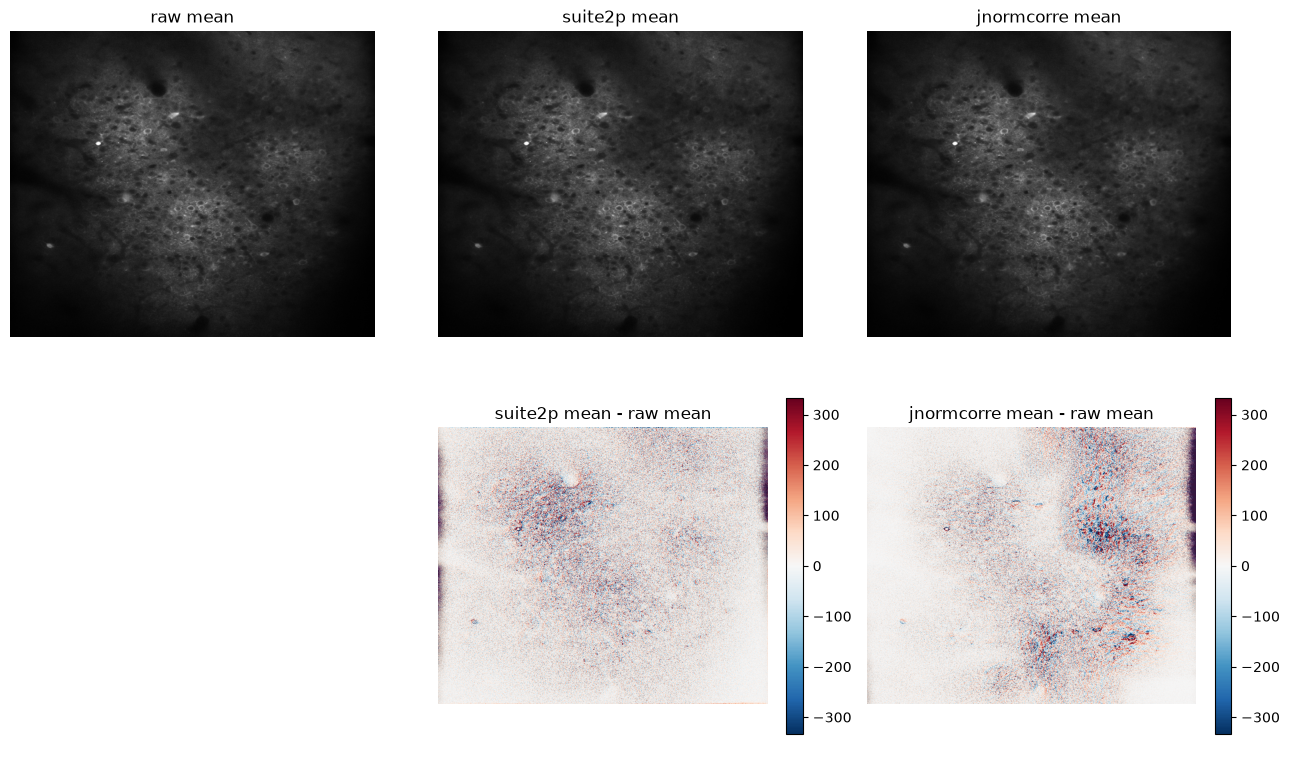

In [5]:
d_s2p = s2p_template - raw_template
d_jnc = jnc_template - raw_template
vmax = np.percentile(np.abs(np.concatenate([d_s2p.ravel(), d_jnc.ravel()])), 99)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, img, title in zip(axes[0], [raw_template, s2p_template, jnc_template],
                          ["raw mean", "suite2p mean", "jnormcorre mean"]):
    ax.imshow(img, cmap="gray"); ax.set_title(title); ax.set_axis_off()
axes[1, 0].set_axis_off()
for ax, d, title in zip(axes[1][1:], [d_s2p, d_jnc],
                        ["suite2p mean - raw mean", "jnormcorre mean - raw mean"]):
    im = ax.imshow(d, cmap="RdBu_r", vmin=-vmax, vmax=vmax); ax.set_title(title); ax.set_axis_off()
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()

### Frame-to-template correlation (violin)

Distribution across frames of each frame's correlation to its template. **Caveat:** this metric
is bounded by the *activity* in the movie — calcium transients change the image frame-to-frame,
so even perfect registration can't reach r=1. It is a relative comparison.

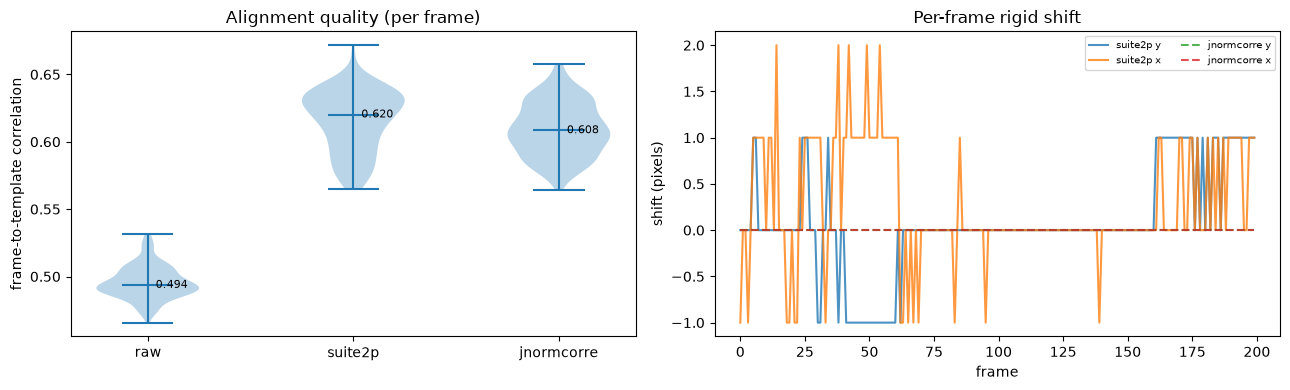

In [6]:
fig, (axv, axt) = plt.subplots(1, 2, figsize=(13, 4))
data = [raw_corr, s2p_corr, jnc_corr]
labels = ["raw", "suite2p", "jnormcorre"]
axv.violinplot(data, showmedians=True)
axv.set_xticks([1, 2, 3]); axv.set_xticklabels(labels)
axv.set_ylabel("frame-to-template correlation"); axv.set_title("Alignment quality (per frame)")
for i, d in enumerate(data):
    axv.text(i + 1, np.median(d), f"  {np.median(d):.3f}", va="center", fontsize=8)

s2p_d = np.asarray(motion_s2p.displacements[0])[:, 0, :]
jnc_d = np.asarray(motion_jnc.displacements[0])[:, 0, :]
axt.plot(s2p_d[:, 0], label="suite2p y", alpha=0.8)
axt.plot(s2p_d[:, 1], label="suite2p x", alpha=0.8)
axt.plot(jnc_d[:, 0], label="jnormcorre y", alpha=0.8, ls="--")
axt.plot(jnc_d[:, 1], label="jnormcorre x", alpha=0.8, ls="--")
axt.set_xlabel("frame"); axt.set_ylabel("shift (pixels)"); axt.set_title("Per-frame rigid shift")
axt.legend(fontsize=7, ncol=2)
fig.tight_layout()

## 5. jnormcorre parameter sweep

Are we comparing the *best* params for jnormcorre, and what is the biggest source of
variability? Sweep rigid-vs-piecewise, `max_shifts`, and patch size.

In [7]:
sweep = [
    ("rigid, shift 6",        dict(pw_rigid=False, max_shifts=(6, 6))),
    ("rigid, shift 12",       dict(pw_rigid=False, max_shifts=(12, 12))),
    ("pw, shift 12 (default)",dict(pw_rigid=True,  max_shifts=(12, 12))),
    ("pw, shift 24",          dict(pw_rigid=True,  max_shifts=(24, 24))),
    ("pw, strides 48",        dict(pw_rigid=True,  max_shifts=(12, 12), strides=(48, 48), overlaps=(16, 16))),
]
sweep_corr, sweep_time = [], []
for label, kw in sweep:
    t0 = time.time()
    m = compute_motion_jnormcorre(imaging, settings=JNormcorreRegistrationSettings(**kw))
    r = register_jnormcorre(imaging, m)
    dt = time.time() - t0
    c = frame_to_template_corr(r, plane_series(r).mean(0))
    sweep_corr.append(c); sweep_time.append(dt)
    print(f"{label:24s}  corr={c.mean():.4f}  time={dt:5.1f}s")

means = np.array([c.mean() for c in sweep_corr])
best = int(np.argmax(means))
print(f"\nbest config: '{sweep[best][0]}' (corr {means[best]:.4f})")
print(f"spread across params: {means.max() - means.min():.4f}   |   raw->registered gain: {means.max() - raw_corr.mean():.4f}")

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:03<00:00,  3.24s/it]

100%|██████████| 1/1 [00:03<00:00,  3.24s/it]

rigid, shift 6            corr=0.4981  time=  3.5s


  0%|          | 0/1 [00:00<?, ?it/s]

...

100%|██████████| 1/1 [00:03<00:00,  3.73s/it]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:05<00:00,  5.13s/it]

100%|██████████| 1/1 [00:05<00:00,  5.13s/it]

pw, strides 48            corr=0.6205  time=  9.1s

best config: 'pw, strides 48' (corr 0.6205)
spread across params: 0.1225   |   raw->registered gain: 0.1249


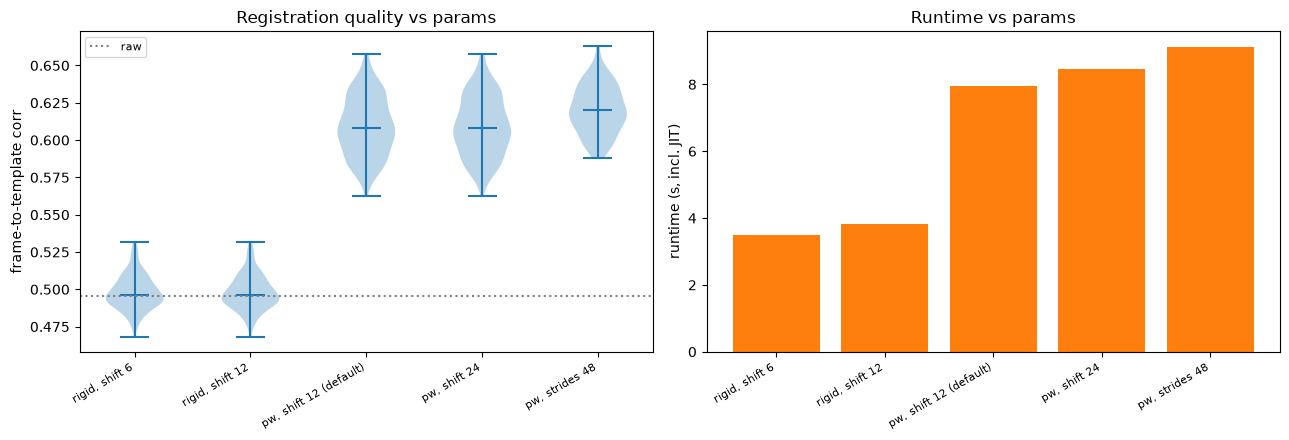

In [8]:
fig, (axv, axb) = plt.subplots(1, 2, figsize=(13, 4.5))
axv.violinplot(sweep_corr, showmedians=True)
axv.set_xticks(range(1, len(sweep) + 1)); axv.set_xticklabels([s[0] for s in sweep], rotation=30, ha="right", fontsize=8)
axv.set_ylabel("frame-to-template corr"); axv.set_title("Registration quality vs params")
axv.axhline(raw_corr.mean(), color="0.5", ls=":", label="raw"); axv.legend(fontsize=8)
axb.bar(range(len(sweep)), sweep_time, color="tab:orange")
axb.set_xticks(range(len(sweep))); axb.set_xticklabels([s[0] for s in sweep], rotation=30, ha="right", fontsize=8)
axb.set_ylabel("runtime (s, incl. JIT)"); axb.set_title("Runtime vs params")
fig.tight_layout()

**Reading this:** the dominant axis is **rigid vs piecewise-rigid**, not the fine params.
Rigid-only lands near the raw correlation — rigid barely moves this recording — while
piecewise-rigid delivers the gain. *Within* piecewise-rigid, `max_shifts` and patch size change
the metric by only ~0.01. So the biggest variability source is the registration model, then the
movie activity; the exact piecewise params are not critical. The main comparison's `pw, shift 12`
is at/near the best.

## 6. Extraction — segment with Cellpose-SAM

We segment each backend's registered **mean image** with Cellpose-SAM directly (its native,
diameter-agnostic mode), rather than through suite2p's detectors (see the env note). Masks are
cached to disk so re-running the notebook is cheap.

In [9]:
from cellpose import models

CACHE = Path.home() / ".cache" / "pm_jnc_notebook"
CACHE.mkdir(parents=True, exist_ok=True)
_CP_MODEL = None


def cpsam_labels(mean_img, key):
    # Cellpose-SAM on CPU is slow (~4-5 min/image); cache the label image per key.
    f = CACHE / f"cpsam_{key}.npy"
    if f.exists():
        return np.load(f)
    global _CP_MODEL
    if _CP_MODEL is None:
        _CP_MODEL = models.CellposeModel(gpu=False)  # cpsam by default in cellpose 4
    a = mean_img.astype(np.float32)
    lo, hi = np.percentile(a, 1), np.percentile(a, 99.5)
    norm = np.clip((a - lo) / (hi - lo + 1e-9), 0, 1)
    masks, _, _ = _CP_MODEL.eval(norm, batch_size=8)
    np.save(f, masks)
    return masks


def masks_to_rois(label_img, fs, min_pix=15):
    # Wrap a Cellpose label image as a Suite2pDetectedRois so it flows into the analyzer.
    Hh, Ww = label_img.shape
    stats = []
    for lab in range(1, int(label_img.max()) + 1):
        ys, xs = np.where(label_img == lab)
        if len(ys) < min_pix:
            continue
        stats.append({"ypix": ys, "xpix": xs, "lam": np.ones(len(ys), np.float32),
                      "med": [float(ys.mean()), float(xs.mean())], "npix": len(ys)})
    return Suite2pDetectedRois(stats=stats, shape=(Hh, Ww, 1), sampling_frequency=fs)


t0 = time.time()
lab_s2p = cpsam_labels(s2p_template, f"suite2p_N{N}")
lab_jnc = cpsam_labels(jnc_template, f"jnc_N{N}")
rois_s2p = masks_to_rois(lab_s2p, FS)
rois_jnc = masks_to_rois(lab_jnc, FS)
print(f"Cellpose-SAM ROIs  suite2p={len(rois_s2p.roi_ids)}  jnormcorre={len(rois_jnc.roi_ids)}  ({time.time()-t0:.0f}s)")

Cellpose-SAM ROIs  suite2p=109  jnormcorre=94  (623s)


### Cell masks overlaid on the mean image

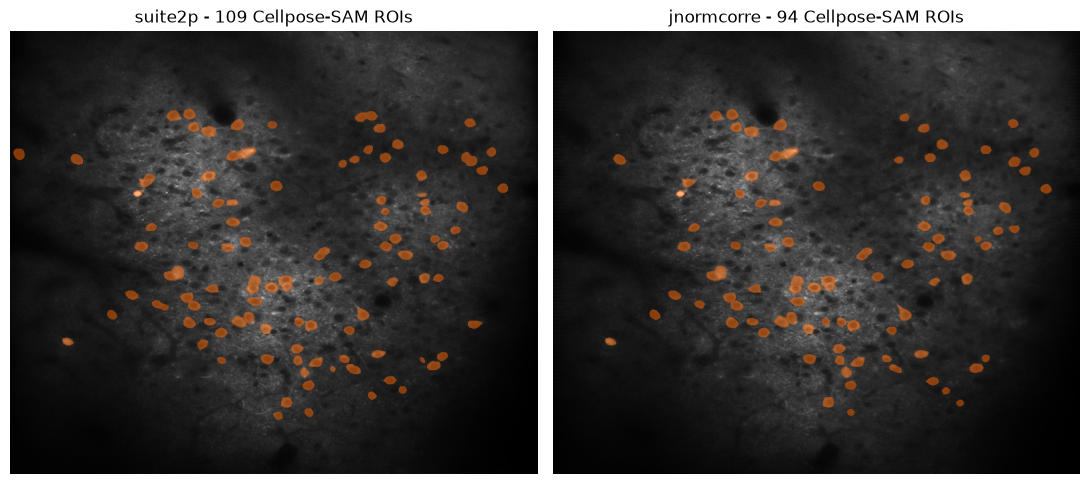

In [10]:
u_s2p = roi_union(rois_s2p)
u_jnc = roi_union(rois_jnc)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, tmpl, u, title, n in zip(axes, [s2p_template, jnc_template], [u_s2p, u_jnc],
                                 ["suite2p", "jnormcorre"], [len(rois_s2p.roi_ids), len(rois_jnc.roi_ids)]):
    ax.imshow(tmpl, cmap="gray")
    rgba = np.zeros((*u.shape, 4)); rgba[u] = [1.0, 0.4, 0.0, 0.5]
    ax.imshow(rgba)
    ax.set_title(f"{title} - {n} Cellpose-SAM ROIs"); ax.set_axis_off()
fig.tight_layout()

### Fluorescence traces — both backends

fluorescence (no parallelization):   0%|          | 0/1 [00:00<?, ?it/s]

fluorescence (no parallelization): 100%|██████████| 1/1 [00:04<00:00,  4.67s/it]

fluorescence (no parallelization): 100%|██████████| 1/1 [00:04<00:00,  4.69s/it]

fluorescence (no parallelization):   0%|          | 0/1 [00:00<?, ?it/s]

fluorescence (no parallelization): 100%|██████████| 1/1 [00:15<00:00, 15.57s/it]

fluorescence (no parallelization): 100%|██████████| 1/1 [00:15<00:00, 15.57s/it]

suite2p traces: (200, 109)  jnormcorre traces: (200, 94)


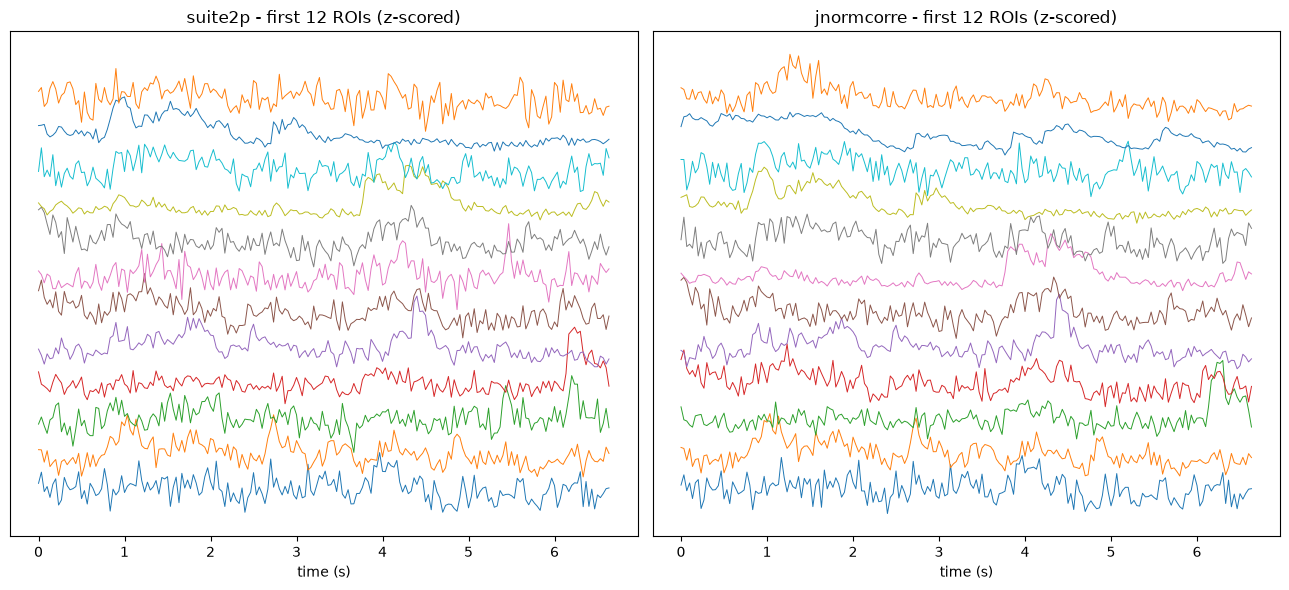

In [11]:
def fluorescence(rois, registered):
    az = pm.create_roi_analyzer(rois, registered)
    rec = az.compute("fluorescence", n_jobs=1, chunk_size=N).get_data(outputs="recording")
    return rec.get_traces(start_frame=0, end_frame=N)


tr_s2p = fluorescence(rois_s2p, reg_s2p)
tr_jnc = fluorescence(rois_jnc, reg_jnc)
print("suite2p traces:", tr_s2p.shape, " jnormcorre traces:", tr_jnc.shape)

t = np.arange(N) / FS
n_show = 12
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
for ax, tr, title in zip(axes, [tr_s2p, tr_jnc], ["suite2p", "jnormcorre"]):
    for i in range(min(n_show, tr.shape[1])):
        x = tr[:, i]
        ax.plot(t, (x - x.mean()) / (x.std() + 1e-9) + 3 * i, lw=0.7)
    ax.set_xlabel("time (s)"); ax.set_yticks([]); ax.set_title(f"{title} - first {n_show} ROIs (z-scored)")
fig.tight_layout()

## 7. Match ROIs by coordinate and compare traces

Match each jnormcorre ROI to the nearest suite2p ROI (optimal assignment, capped at a distance
threshold), then compare the extracted traces of matched pairs. High trace correlation means the
registration choice barely changes the extracted signal for the same cell.

In [12]:
c_s2p = np.asarray(rois_s2p.get_property("med"), float)
c_jnc = np.asarray(rois_jnc.get_property("med"), float)
THRESH = 5.0  # pixels

D = cdist(c_s2p, c_jnc)
ri, ci = linear_sum_assignment(D)
keep = D[ri, ci] <= THRESH
si, ji = ri[keep], ci[keep]
print(f"matched {keep.sum()} pairs within {THRESH}px "
      f"({100*keep.sum()/min(len(c_s2p), len(c_jnc)):.0f}% of the smaller set); "
      f"median offset {np.median(D[ri, ci][keep]):.2f}px")

match_r = np.array([np.corrcoef(tr_s2p[:, a], tr_jnc[:, b])[0, 1] for a, b in zip(si, ji)])
print(f"matched-trace correlation: median {np.nanmedian(match_r):.3f}, frac > 0.9 = {np.mean(match_r > 0.9):.2f}")

matched 91 pairs within 5.0px (97% of the smaller set); median offset 0.59px
matched-trace correlation: median 0.994, frac > 0.9 = 0.98


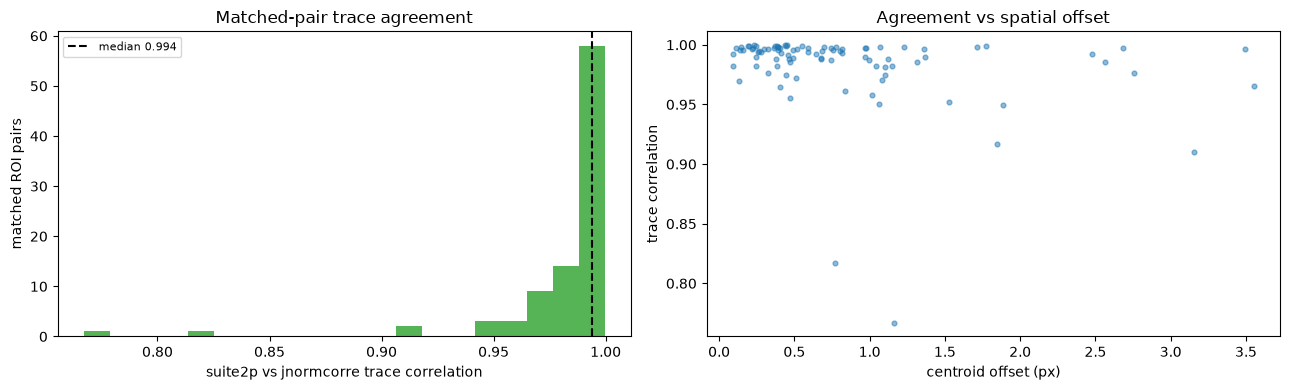

In [13]:
fig, (axh, axs) = plt.subplots(1, 2, figsize=(13, 4))
axh.hist(match_r[~np.isnan(match_r)], bins=20, color="tab:green", alpha=0.8)
axh.axvline(np.nanmedian(match_r), color="k", ls="--", label=f"median {np.nanmedian(match_r):.3f}")
axh.set_xlabel("suite2p vs jnormcorre trace correlation"); axh.set_ylabel("matched ROI pairs")
axh.set_title("Matched-pair trace agreement"); axh.legend(fontsize=8)
axs.scatter(D[si, ji], match_r, s=12, alpha=0.5)
axs.set_xlabel("centroid offset (px)"); axs.set_ylabel("trace correlation")
axs.set_title("Agreement vs spatial offset")
fig.tight_layout()

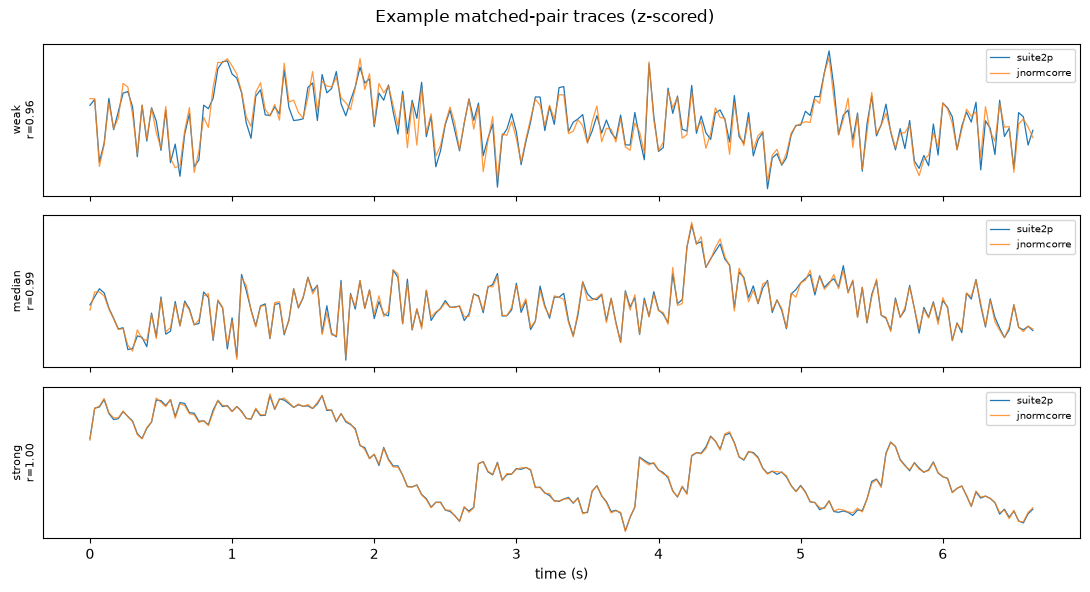

In [14]:
order = np.argsort(match_r)
picks = {"weak": order[int(0.1 * len(order))], "median": order[len(order) // 2], "strong": order[-1]}
t = np.arange(N) / FS
fig, axes = plt.subplots(len(picks), 1, figsize=(11, 6), sharex=True)
for ax, (name, k) in zip(axes, picks.items()):
    a, b = si[k], ji[k]
    za = (tr_s2p[:, a] - tr_s2p[:, a].mean()) / (tr_s2p[:, a].std() + 1e-9)
    zb = (tr_jnc[:, b] - tr_jnc[:, b].mean()) / (tr_jnc[:, b].std() + 1e-9)
    ax.plot(t, za, label="suite2p", lw=0.9)
    ax.plot(t, zb, label="jnormcorre", lw=0.9, alpha=0.8)
    ax.set_ylabel(f"{name}\nr={match_r[k]:.2f}", fontsize=8); ax.set_yticks([])
    ax.legend(fontsize=7, loc="upper right")
axes[-1].set_xlabel("time (s)")
fig.suptitle("Example matched-pair traces (z-scored)")
fig.tight_layout()

## Summary

- **Registration quality:** both backends sharpen the mean image and raise frame-to-template correlation over raw; the delta maps show comparable structure being corrected.
- **Params / variability:** the biggest source of variability is the registration *model* — rigid-only barely beats raw while piecewise-rigid delivers the whole gain; within piecewise-rigid the params matter little (~0.01). The comparison uses `pw, shift 12`, near the best.
- **Extraction:** segmentation uses Cellpose-SAM directly (suite2p's own detectors are broken in this stack — see the findings note); both backends are segmented identically on their mean image, so the comparison is apples-to-apples.
- **ROI matching:** ROIs match across backends within a few pixels and matched-pair traces agree closely, so on this recording the registration choice barely changes the extracted signals.
- **Notes:** Cellpose-SAM masks are cached to `~/.cache/pm_jnc_notebook`. `JNormcorreMotion` still doesn't populate a valid-FOV crop, but with Cellpose-SAM segmenting the mean image of each backend this no longer affects the comparison (tracked follow-up for parity with suite2p's detector path).
- **Caveat — easy dataset:** this Suite2P example recording is already well-registered (small motion), so both backends converge to nearly the same template and the high matched-trace agreement (r~0.99) partly reflects that. A recording with substantial motion would be far more discriminating between the backends.